In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

from mtpy import MTData
from mtpy.modeling import StructuredGrid3D


In [2]:
save_path = Path(r"c:\Users\jpeacock\OneDrive - DOI\Geothermal\GreatBasin\modem_inv\mina_inv_01")
save_path.mkdir(exist_ok=True, parents=True)

In [3]:
topo_fn = Path(r"c:\Users\jpeacock\OneDrive - DOI\western_us.tiff")

# Build Data File

In [4]:
md = MTData()
md.from_modem(r"c:\Users\jpeacock\OneDrive - DOI\Geothermal\GreatBasin\modem_inv\mina_inv_01\mina_modem_data_z03_t02_tec_02.dat")



In [ ]:
md.z_model_error.error_value =0.03
md.z_model_error.error_type = "eigen"
md.z_model_error.floor = True
md.t_model_error.error_value = 0.02
md.t_model_error.error_type = "absolute"
md.t_model_error.floor = True

md.compute_model_errors()

In [ ]:
modem_md = md.to_modem(save_path / "mina_modem_data_z03_t02.dat")

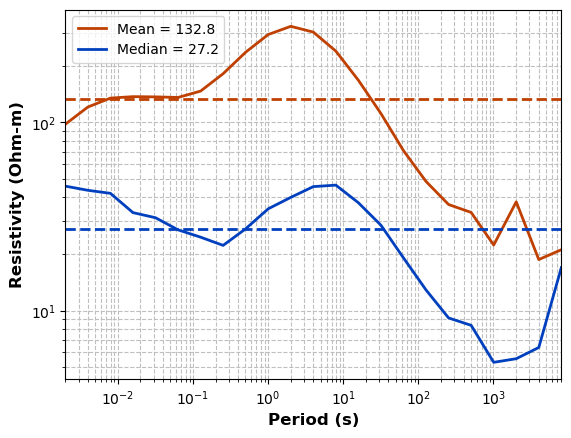

In [5]:
md.estimate_starting_rho()

In [6]:
md.station_locations.elevation.min()

np.float64(-6009.999)

# Make Model 

26:03:26T13:26:32 | WARNING | line:1691 |mtpy.modeling.structured_mesh_3d | _validate_extent | Provided or default ew_ext not sufficient to fit stations + padding, updating extent
26:03:26T13:26:32 | WARNING | line:1697 |mtpy.modeling.structured_mesh_3d | _validate_extent | Provided or default ns_ext not sufficient to fit stations + padding, updating extent


Structured3DMesh Model Object:
--------------------
	Number of stations = 385
	Mesh Parameter: 
		cell_size_east:    1250
		cell_size_north:   1250
		pad_east:          10
		pad_north:         10
		pad_num:           5
		z1_layer:          30
		z_target_depth:    80000
		n_layers:          65
		n_air_layers:      25
		res_initial_value: 80
	Dimensions: 
		e-w: 168
		n-s: 179
		z:   66 (without 7 air layers)
	Extensions: 
		e-w:  369750.0 (m)
		n-s:  365500.0 (m)
		0-z:  384995.9 (m)
--------------------
Read geotiff surface file
1202.06005859375 3100
26:03:26T13:26:33 | INFO | line:1629 |mtpy.modeling.structured_mesh_3d | add_topography_to_model | Using constant air layer thickness of 30 m, which results in 64.0 air layers to cover the topography


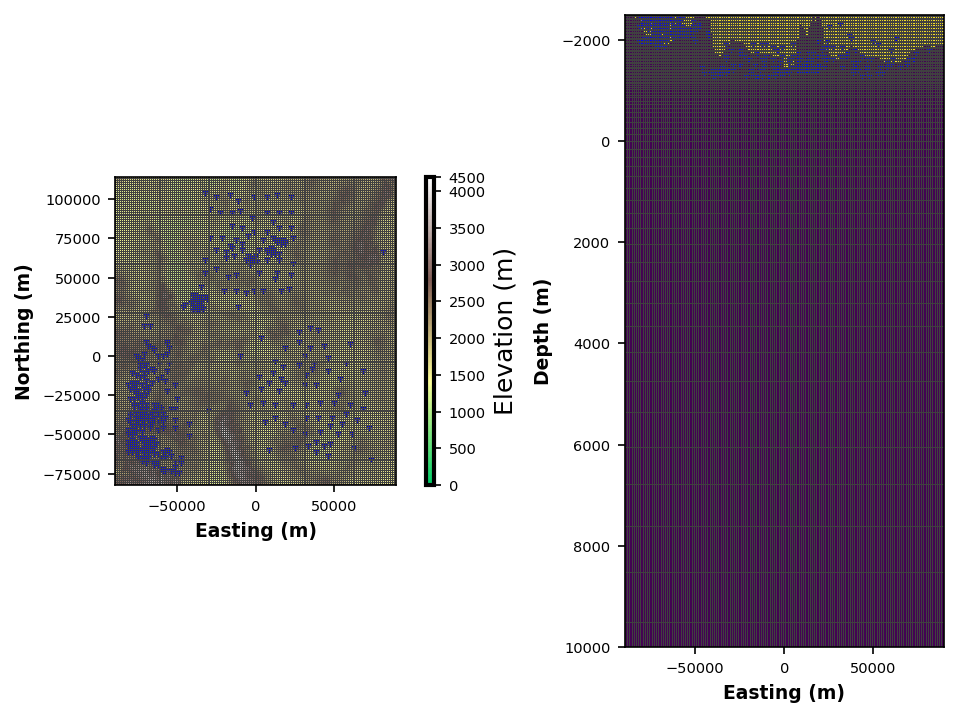

26:03:26T13:26:41 | INFO | line:830 |mtpy.modeling.structured_mesh_3d | to_modem | Wrote file to: c:\Users\jpeacock\OneDrive - DOI\Geothermal\GreatBasin\modem_inv\mina_inv_01\mina_sm80.rho
Structured3DMesh Model Object:
--------------------
	Number of stations = 385
	Mesh Parameter: 
		cell_size_east:    1250
		cell_size_north:   1250
		pad_east:          10
		pad_north:         10
		pad_num:           5
		z1_layer:          30
		z_target_depth:    80000
		n_layers:          65
		n_air_layers:      64
		res_initial_value: 80
	Dimensions: 
		e-w: 168
		n-s: 179
		z:   130 (without 7 air layers)
	Extensions: 
		e-w:  369750.0 (m)
		n-s:  365500.0 (m)
		0-z:  386915.9 (m)
--------------------


In [7]:
s = StructuredGrid3D(
    station_locations=md.station_locations,
    center_point=md.center_point,
)

s.cell_size_east = 1250
s.cell_size_north = 1250
s.pad_east = 10
s.pad_north = 10
s.pad_num = 5
s.ew_ext = 300000
s.ns_ext = 300000
s.z_mesh_method = "default"
s.z_bottom = 600000
s.z_target_depth = 80000
s.pad_z = 6
s.n_air_layers = 25
s.n_layers = 65
s.z1_layer = 30
s.pad_stretch_v = 1.6
s.z_layer_rounding = 1
s.res_initial_value = 80

s.make_mesh()

s.add_topography_to_model(
    topography_file=topo_fn,
    max_elev=3100,
    airlayer_type="constant",
    shift_east=0,
    shift_north=0,
)

md.compute_relative_locations()
md.center_stations(s)
md.project_stations_on_topography(s)

s.station_locations = md.station_locations
s.plot_mesh(z_limits=(10000, -2500), show_stations=True)
s.to_modem(save_path / "mina_sm80.rho")

print(s)


In [8]:
md = MTData()
md.from_modem(save_path / "mina_modem_data_z03_t02_tec_02.dat") 

s = StructuredGrid3D(md.station_locations, center_point=md.center_point)
s.from_modem(save_path / "mina_sm80.rho")


md.compute_relative_locations()
md.center_stations(s)
md.project_stations_on_topography(s)
md.to_modem(save_path / "mina_modem_data_z03_t02_tec_03.dat", inv_mode="1")
md.z_model_error.error_value = 10
md.z_model_error.error_type = "eigen"
md.t_model_error.error_value = 0.03
md.compute_model_errors()

survey = "mina"
md.to_modem(save_path / (f"{survey}_modem_data_z10_tec.dat"), inv_mode="2")
md.to_modem(save_path / (f"{survey}_modem_data_t03_tec.dat"), inv_mode="5")

26:03:26T13:30:03 | WARNING | line:539 |mtpy.modeling.modem.data | _check_for_too_small_errors | Found errors with values less than 0.02 in t_zx 44 times. Setting error as t_zx x 0.02.
26:03:26T13:30:03 | WARNING | line:539 |mtpy.modeling.modem.data | _check_for_too_small_errors | Found errors with values less than 0.02 in t_zy 172 times. Setting error as t_zy x 0.02.
26:03:26T13:30:03 | WARNING | line:571 |mtpy.modeling.modem.data | _check_for_too_small_values | Found values in t_zx smaller than 1e-10 816 times. Setting to nan
26:03:26T13:30:03 | WARNING | line:571 |mtpy.modeling.modem.data | _check_for_too_small_values | Found values in t_zy smaller than 1e-10 816 times. Setting to nan
26:03:26T13:30:07 | INFO | line:652 |mtpy.modeling.modem.data | write_data_file | Wrote ModEM data file to c:\Users\jpeacock\OneDrive - DOI\Geothermal\GreatBasin\modem_inv\mina_inv_01\mina_modem_data_z03_t02_tec_03.dat
26:03:26T13:30:07 | WARNING | line:1179 |mtpy.core.mt | compute_model_t_errors | MT 

ModEM Data Object:
	Number of impedance stations: 385
	Number of tipper stations: 385
	Number of phase tensor stations: 385
	Number of periods:  23
	Period range (s):  
		Min: 0.002
		Max: 8000
	Rotation angle:     0.0
	Data center:        
		Latitude:   38.2226 deg 	Northing: 4231103.6369 m
		Longitude: -118.1208 deg 	Easting: 401891.4066 m
		Datum epsg: 4326			UTM epsg:   32611
		Elevation:  -3122.0 m
	Impedance data:     True
	Tipper data:        True
	Inversion Mode:   Full_Vertical_Components

In [9]:
from mtpy.modeling.modem import Covariance

cov = Covariance(grid_dimensions=s.res_model.shape)
cov.smoothing_east = 0.7
cov.smoothing_north = 0.7
cov.smoothing_vertical = 0.4
cov.write_covariance_file(save_path / "mina_covariance.cov")


26:03:26T13:43:00 | INFO | line:232 |mtpy.modeling.modem.convariance | write_covariance_file | Wrote covariance file to c:\Users\jpeacock\OneDrive - DOI\Geothermal\GreatBasin\modem_inv\mina_inv_01\mina_covariance.cov


In [23]:
500 * np.sqrt(1./700*30)

np.float64(103.50983390135313)

In [11]:
mdv = MTData()
mdv.add_station(list(Path(r"c:\Users\jpeacock\OneDrive - DOI\SAGE\EDI_Files\renamed").rglob("*.edi")))
mdv.to_shp(r"c:\Users\jpeacock\OneDrive - DOI\SAGE\EDI_Files\renamed\sage_mt_stations_all.shp")

26:03:26T16:41:53 | WARNING | line:432 |mt_metadata.common.units | get_unit_from_df | Unit 'millivolts' not found in accepted units, setting to 'unknown'. If this is an error raise an issue to add a unit. If an error needs to be raised, set allow_none=False.
26:03:26T16:41:53 | WARNING | line:432 |mt_metadata.common.units | get_unit_from_df | Unit 'millivolts' not found in accepted units, setting to 'unknown'. If this is an error raise an issue to add a unit. If an error needs to be raised, set allow_none=False.
26:03:26T16:41:54 | WARNING | line:432 |mt_metadata.common.units | get_unit_from_df | Unit 'millivolts' not found in accepted units, setting to 'unknown'. If this is an error raise an issue to add a unit. If an error needs to be raised, set allow_none=False.
26:03:26T16:41:54 | WARNING | line:432 |mt_metadata.common.units | get_unit_from_df | Unit 'millivolts' not found in accepted units, setting to 'unknown'. If this is an error raise an issue to add a unit. If an error needs 

'c:\\Users\\jpeacock\\OneDrive - DOI\\SAGE\\EDI_Files\\renamed\\sage_mt_stations_all.shp'